In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from PIL import Image

### Configuration

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_path = 'data/17flowerclasses'

### Data Preprocessing and Augmentation

In [4]:
normalizer = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.45, saturation=0.2),
    transforms.ToTensor(),
    normalizer
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalizer
])

### Loading the Dataset

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(os.path.join(data_path, 'test'), transform=transform_test)

### Creating DataLoaders

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [7]:
class_names = train_dataset.classes
class_names, len(class_names)

(['Bluebell',
  'ButterCup',
  'ColtsFoot',
  'Cowslip',
  'Crocus',
  'Daffodil',
  'Daisy',
  'Dandelion',
  'Fritillary',
  'Iris',
  'LilyValley',
  'Pansy',
  'Snowdrop',
  'Sunflower',
  'Tigerlily',
  'WindFlower',
  'tulip'],
 17)

### Model Architecture

We use **ResNet18** with pre-trained weights from ImageNet. Only the final fully connected layer is modified to output 17 classes instead of 1000.

This approach leverages features learned from millions of images, which is crucial for achieving high accuracy on small datasets.

In [8]:
model = models.resnet18(pretrained=True) 
num_features = model.fc.in_features
num_features

i:\miniconda3\envs\ml\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
i:\miniconda3\envs\ml\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


512

In [9]:
model.fc = nn.Linear(num_features, len(class_names))
model = model.to(device)

### Loss Function and Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training

In [11]:
epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.3f} | Acc: {100.*correct/total:.2f}%")


Epoch 1 | Loss: 1.294 | Acc: 61.18%
Epoch 2 | Loss: 0.898 | Acc: 72.10%
Epoch 3 | Loss: 0.760 | Acc: 77.65%
Epoch 4 | Loss: 0.614 | Acc: 81.68%
Epoch 5 | Loss: 0.571 | Acc: 83.95%
Epoch 6 | Loss: 0.574 | Acc: 82.44%
Epoch 7 | Loss: 0.616 | Acc: 82.52%
Epoch 8 | Loss: 0.513 | Acc: 84.12%
Epoch 9 | Loss: 0.522 | Acc: 84.87%
Epoch 10 | Loss: 0.486 | Acc: 85.04%
Epoch 11 | Loss: 0.474 | Acc: 85.80%
Epoch 12 | Loss: 0.419 | Acc: 86.39%
Epoch 13 | Loss: 0.414 | Acc: 86.81%
Epoch 14 | Loss: 0.423 | Acc: 86.81%
Epoch 15 | Loss: 0.373 | Acc: 87.73%


### Evaluation

In [16]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
print(f'Test Acc: {100. * correct / total}%')

Test Acc: 91.17647058823529%


### Inference on External Images

In [26]:
def check_image(path, true_label):
    img = Image.open(path).convert('RGB')
    tensor = transform_test(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(tensor)
        _, pred = torch.max(out, 1)
        
    plt.imshow(img)
    plt.title(f"Model Prediction: {class_names[pred[0]]}\nTrue Label: {true_label}")
    plt.axis('off')
    plt.show()

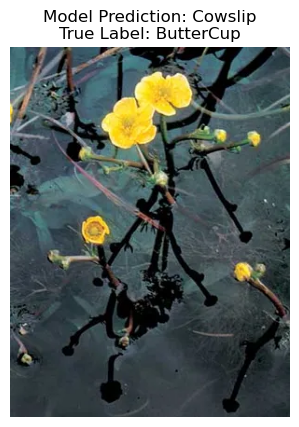

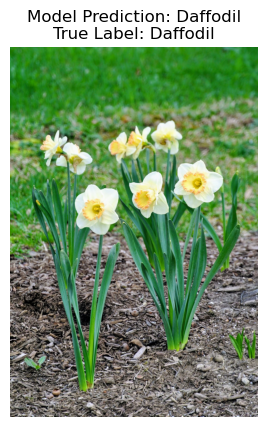

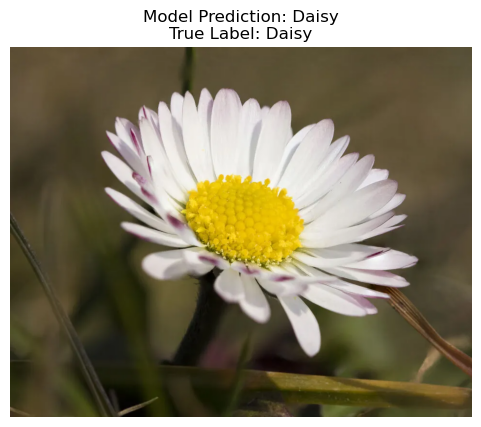

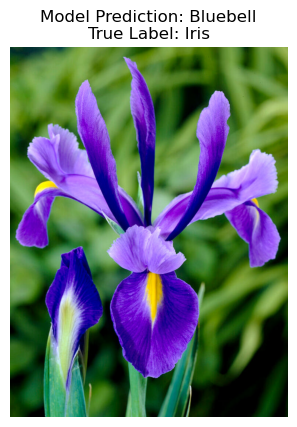

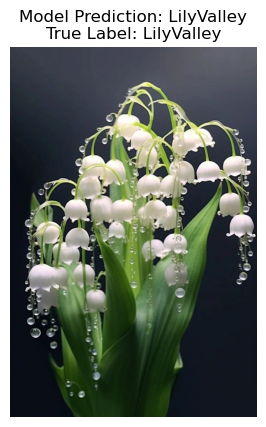

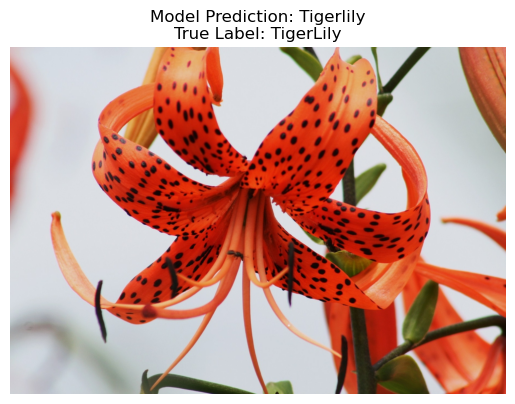

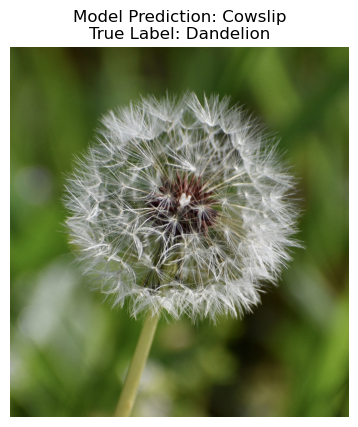

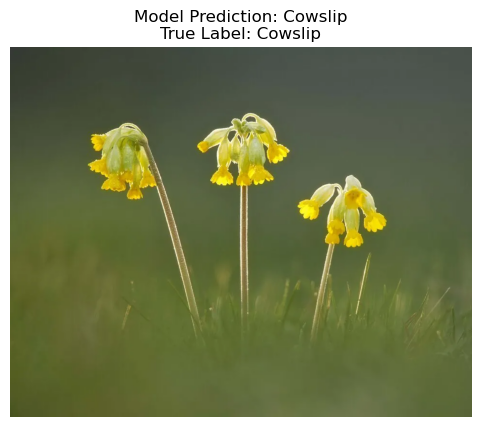

In [27]:
check_image("images/buttercup.png", "ButterCup")
check_image("images/daffodil.png", "Daffodil")
check_image("images/daisy.png", "Daisy")
check_image("images/iris.png", "Iris")
check_image("images/lilyvalley.png", "LilyValley")
check_image("images/tigerlily.png", "TigerLily")
check_image("images/dandelion.png", "Dandelion")
check_image("images/cowslip.png", "Cowslip")


### Report


# گزارش تمرین: طبقه‌بندی گل‌ها با شبکه CNN

**نام:** علی طبیب آذر

---

## 1. مقدمه

در این تمرین، یک شبکه CNN برای طبقه‌بندی 17 نوع گل بر روی دیتاست Flower17 پیاده‌سازی شده است. با توجه به حجم محدود دیتاست (حدود 1360 تصویر)، آموزش یک شبکه عمیق از صفر با چالش Overfitting مواجه خواهد شد. به همین دلیل از رویکرد **Transfer Learning** با مدل از پیش آموزش‌دیده ResNet18 استفاده شده است.

## 2. دیتاست

دیتاست Flower17 از آدرس زیر دانلود شده است:

[https://www.kaggle.com/datasets/aima138/17flowerclasses](https://www.kaggle.com/datasets/aima138/17flowerclasses)

این دیتاست شامل ۱۷ کلاس از انواع گل‌ها است که هر کلاس در یک پوشه مجزا قرار دارد.



## 3. روش کار

### 3.1. انتخاب معماری مدل

به دلیل کوچک بودن دیتاست، آموزش یک CNN از صفر منجر به Overfitting شدید خواهد شد. بنابراین از مدل `ResNet18` با وزن‌های از پیش آموزش‌دیده روی ImageNet استفاده شد. دلایل انتخاب این معماری:

- **کارایی در دیتاست‌های کوچک:** لایه‌های اولیه شبکه، ویژگی‌های پایه مانند لبه‌ها و بافت‌ها را از قبل آموخته‌اند.
- **سرعت مناسب:** ResNet18 نسبت به مدل‌های عمیق‌تر، سبک‌تر بوده و زمان آموزش کمتری نیاز دارد.
- **دقت قابل قبول:** با Fine-tune کردن لایه آخر، دقت مناسبی برای 17 کلاس حاصل می‌شود.

در این پیاده‌سازی، تنها لایه Fully Connected پایانی شبکه تغییر داده شده است:

```python
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))
```


### 3.2. Data Augmentation

برای افزایش تنوع داده و جلوگیری از Overfitting، در مرحله آموزش از تکنیک‌های Data Augmentation استفاده شد:

| تکنیک | توضیح |
|--------|--------|
| `RandomResizedCrop(224)` | برش تصادفی و تغییر سایز تصویر |
| `RandomHorizontalFlip()` | چرخش افقی تصادفی |
| `RandomRotation(20)` | چرخش تا 20 درجه |
| `ColorJitter` | تغییرات تصادفی در روشنایی، کنتراست و اشباع رنگ |

## 4. پیاده‌سازی

پیاده‌سازی با فریمورک PyTorch انجام شده است. مراحل کار:

**مرحله اول - بارگذاری داده:**

از `ImageFolder` برای خواندن خودکار تصاویر از ساختار پوشه‌ها استفاده شد.

**مرحله دوم - تعریف مدل:**

مدل ResNet18 با وزن‌های ImageNet بارگذاری شد و لایه خروجی برای 17 کلاس تنظیم گردید.

**مرحله سوم - آموزش:**

مدل با Optimizer Adam (نرخ یادگیری 0.001) و تابع هزینه CrossEntropyLoss به مدت 15 Epoch آموزش داده شد.

**مرحله چهارم - ارزیابی:**

مدل نهایی بر روی دیتاست تست ارزیابی شد.

## 5. نتایج آموزش

روند تغییرات Loss و دقت در طول 15 Epoch:

| Epoch | Loss | Train Accuracy |
|-------|------|----------------|
| 1 | 1.294 | 61.18% |
| 2 | 0.898 | 72.10% |
| 3 | 0.760 | 77.65% |
| 4 | 0.614 | 81.68% |
| 5 | 0.571 | 83.95% |
| 6 | 0.574 | 82.44% |
| 7 | 0.616 | 82.52% |
| 8 | 0.513 | 84.12% |
| 9 | 0.522 | 84.87% |
| 10 | 0.486 | 85.04% |
| 11 | 0.474 | 85.80% |
| 12 | 0.419 | 86.39% |
| 13 | 0.414 | 86.81% |
| 14 | 0.423 | 86.81% |
| 15 | 0.373 | 87.73% |

**نتیجه نهایی:**

| معیار | مقدار |
|--------|--------|
| دقت آموزش نهایی | 87.73% |
| **دقت تست نهایی** | **91.18%** |

### تحلیل نتایج

نکته قابل توجه این است که دقت تست (91.18%) از دقت آموزش (87.73%) بالاتر است. این پدیده به دو دلیل رخ می‌دهد:

1. در حین آموزش، Data Augmentation فعال است و تصاویر به صورت تصادفی برش، چرخش و تغییر رنگ می‌شوند. این کار آموزش را دشوارتر کرده و دقت در هر Epoch پایین‌تر به نظر می‌رسد.

2. در مرحله تست، تصاویر بدون هیچ‌گونه تغییر و فقط با `Resize` و `CenterCrop` پردازش می‌شوند. بنابراین مدل با تصاویر تمیزتر و استانداردتری مواجه است.

این نتیجه نشان می‌دهد مدل به خوبی جنرالایز کرده و Overfitting رخ نداده است.

## 6. اینفرنس بر روی تصاویر خارجی

برای ارزیابی نهایی، چند تصویر از انواع گل که در دیتاست وجود نداشتند، از اینترنت دانلود و به مدل داده شد. تابع `check_image` تصویر را بارگذاری، پیش‌پردازش و پیش‌بینی کرده و نتیجه را به همراه تصویر نمایش می‌دهد.

مدل توانست نوع گل‌های خارجی را به درستی تشخیص دهد.

## 7. نتیجه‌گیری

این پروژه نشان داد که برای دیتاست‌های کوچک، استفاده از Transfer Learning بسیار مؤثرتر از آموزش شبکه از صفر است. با استفاده از ResNet18 و تکنیک‌های Data Augmentation، دقت **91.18%** بر روی دیتاست تست حاصل شد که شرط بالای 90% را برآورده می‌کند.